In [1]:
import sys

In [5]:
assert sys.version_info >= (3, 7)

In [7]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [8]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [9]:
import pandas as pd
import numpy as np

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
df = pd.read_csv('lifesat.csv')

In [13]:
df.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


In [16]:
df.shape

(27, 3)

In [18]:
df.isnull().sum()

Country                 0
GDP per capita (USD)    0
Life satisfaction       0
dtype: int64

In [19]:
df.describe()

,GDP per capita (USD),Life satisfaction
count,27.000000,27.000000
mean,41564.521771,6.566667
std,9631.452319,0.765607
min,26456.387938,5.400000
25%,33938.289305,5.900000
50%,41627.129269,6.800000
75%,49690.580269,7.300000
max,60235.728492,7.600000


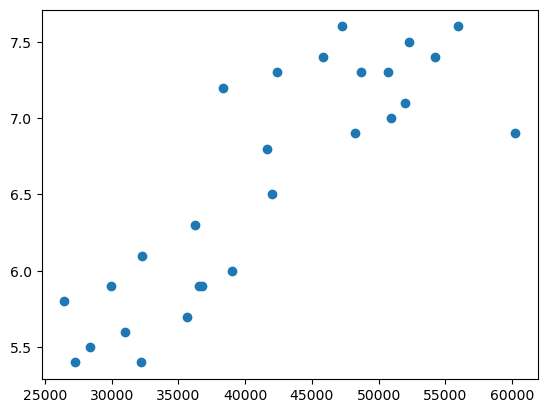

In [42]:
plt.scatter(x=df['GDP per capita (USD)'], y=df['Life satisfaction'])

In [30]:
X = df[['GDP per capita (USD)']]

In [25]:
y = df[['Life satisfaction']]

In [31]:
print(X.shape) #because model needs 2d objects
print(y.shape)

(27, 1)
(27, 1)


In [38]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [39]:
model.coef_

array([[6.77889969e-05]])

In [40]:
model.intercept_

array([3.74904943])

In [44]:
df.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


### Making prediction for India (per capita GDP = 3051$ (2026))

In [50]:
new_df = pd.DataFrame({"GDP per capita (USD)" : [3051]})
new_X = new_df[["GDP per capita (USD)"]]
model.predict(new_X)

array([[3.95587366]])

In [70]:
num = np.linspace(25000, 62000)
df1 = pd.DataFrame({"GDP per capita (USD)" : num})

In [73]:
res = model.predict(df1)

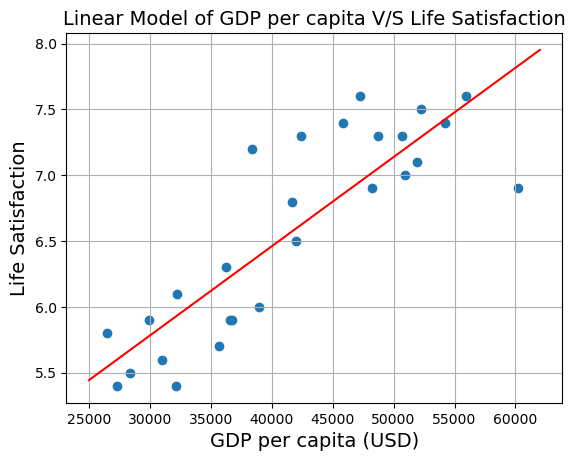

In [82]:
plt.scatter(x=df['GDP per capita (USD)'], y=df['Life satisfaction'])
plt.plot(num, res.flatten(), color='red')
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Life Satisfaction")
plt.title("Linear Model of GDP per capita V/S Life Satisfaction")
plt.grid(True)
plt.show()

### Using an instance based approach ( k-nearest neighbors regression )

In [83]:
from sklearn.neighbors import KNeighborsRegressor

In [84]:
newModel = KNeighborsRegressor(n_neighbors=3)

In [85]:
newModel.fit(X, y)

KNeighborsRegressor(n_neighbors=3)

In [88]:
newModel.predict(new_X)

array([[5.56666667]])

#### Inference -> This is quite high as compared to Linear Regression, beacuse KNN have data of minimum 25K per capita GDP while India have per capita GDP of only 3051$ which is far less, so Linear Regression Performs better here (depending on available data).

In [89]:
res_knn = newModel.predict(df1)

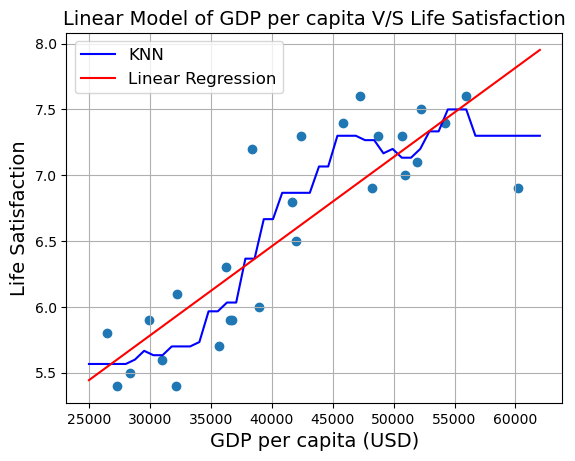

In [92]:
plt.scatter(x=df['GDP per capita (USD)'], y=df['Life satisfaction'])
plt.plot(num, res_knn.flatten(), color='blue', label='KNN')
plt.plot(num, res.flatten(), color='red', label='Linear Regression')
plt.legend()
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Life Satisfaction")
plt.title("Linear Model of GDP per capita V/S Life Satisfaction")
plt.grid(True)
plt.show()